# 03 - Phân tích Khám phá & Mã hóa dữ liệu (EDA & Encoding)

### Phát biểu bài toán:
- **Mục tiêu:** Phân tích mức độ ảnh hưởng của các thông số kỹ thuật (Pin, Trọng lượng, tính năng Wireless...) và Thương hiệu đến giá của tai nghe.
- **Bài toán:** Khảo sát tính khả thi để xây dựng mô hình dự đoán `price_vnd` (biến số liên tục) -> Đây là bài toán **Hồi quy (Regression)**.

### Các bước thực hiện trong Notebook này:
1. **Thiết lập & Nạp dữ liệu:** Chuẩn bị môi trường và dữ liệu sạch.
2. **Feature Engineering:** Trích xuất các đặc trưng công nghệ mới.
3. **Trực quan hóa đa biến (EDA Nâng cao):** Khám phá mối quan hệ giữa các biến.
4. **Mã hóa dữ liệu (Data Encoding):** Chuyển đổi dữ liệu chữ sang số cho Machine Learning.
5. **Phân tích đa chiều (t-SNE):** Khảo sát tính phân cụm của dữ liệu.

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os

# Cấu hình giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)

# Hàm rút gọn tiền tệ (Ví dụ: 5.000.000 -> 5 Tr)
def millions_formatter(x, pos):
    return f'{x * 1e-6:g} Tr'
formatter = ticker.FuncFormatter(millions_formatter)

# Đọc dữ liệu đã clean từ bước trước
file_path = '../clean_data/headphone_clean.csv'
df = pd.read_csv(file_path)
print(f"Đã nạp thành công dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")

Đã nạp thành công dữ liệu: 986 dòng, 13 cột.


## 3.1. Gom nhóm dữ liệu (Tránh bùng nổ số chiều)
Biến `brand` có quá nhiều giá trị phân biệt. Ta sẽ giữ Top 15 hãng lớn nhất, gộp các hãng nhỏ thành nhóm `Other`.

In [96]:
df_encoded = df.copy()

if 'brand' in df_encoded.columns:
    top_15_brands = df_encoded['brand'].value_counts().nlargest(15).index
    df_encoded['brand_grouped'] = df_encoded['brand'].apply(lambda x: x if x in top_15_brands else 'Other')
    
    # Xóa bỏ cột brand cũ để tránh trùng lặp thông tin
    df_encoded = df_encoded.drop(columns=['brand'])
    
    print("Phân phối thương hiệu sau khi gộp nhóm:")
    print(df_encoded['brand_grouped'].value_counts())

Phân phối thương hiệu sau khi gộp nhóm:
brand_grouped
Other              333
Havit               74
Apple (Macbook)     74
JBL                 65
Soundpeats          57
Baseus              52
Edifier             51
ASUS                46
Logitech            39
Anker               33
Hãng khác           32
Sony                31
Xiaomi              30
Sennheiser          28
Razer               26
Huawei              15
Name: count, dtype: int64


## 3.2. One-Hot Encoding
Biến đổi các biến danh mục (`brand_grouped`, `type`...) thành vector nhị phân 0 và 1.

In [79]:
# Xác định các danh sách cột cần mã hóa
cols_to_encode = ['brand_grouped', 'type']
cols_to_encode = [c for c in cols_to_encode if c in df_encoded.columns]

if cols_to_encode:
    # Thực hiện mã hóa One-Hot
    df_encoded = pd.get_dummies(df_encoded, columns=cols_to_encode, drop_first=True)
    
    # Ép kiểu dữ liệu Boolean (True/False) về dạng số (1/0)
    for col in df_encoded.columns:
        if df_encoded[col].dtype == bool:
            df_encoded[col] = df_encoded[col].astype(int)

print(f"Kích thước tập dữ liệu sau khi mã hóa: {df_encoded.shape}")
display(df_encoded.head())

Kích thước tập dữ liệu sau khi mã hóa: (986, 27)


,source,url,name,price_raw,price_vnd,is_gaming,is_wireless,has_mic,connection,battery_life_hours,...,brand_grouped_Hãng khác,brand_grouped_JBL,brand_grouped_Logitech,brand_grouped_Other,brand_grouped_Razer,brand_grouped_Sennheiser,brand_grouped_Sony,brand_grouped_Soundpeats,brand_grouped_Xiaomi,type_over-ear
0,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-1000XM6,11.990.000đ,11990000,0,1,0,3.5mm,40,...,0,0,0,0,0,0,1,0,0,1
1,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-se...,Tai nghe chụp tai Sennheiser HDB 630,14.900.000đ,14900000,0,0,0,NaN,60,...,0,0,0,0,0,1,0,0,0,1
2,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-1000XM5,7.990.000đ,7990000,0,1,0,3.5mm,NaN,...,0,0,0,0,0,0,1,0,0,1
3,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-CH520,1.290.000đ,1290000,0,1,0,NaN,50,...,0,0,0,0,0,0,1,0,0,1
4,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-jb...,Tai nghe Bluetooth chụp tai JBL Tune 520BT,1.360.000đ,1360000,0,1,0,Type C,57,...,0,1,0,0,0,0,0,0,0,1


## 3.3. Xuất dữ liệu (Export)

In [80]:
import os

# Lưu file dữ liệu đã mã hóa hoàn tất
out_dir = '../clean_data/'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'headphone_encoded_for_ml.csv')

df_encoded.to_csv(out_path, index=False)
print(f"Đã lưu thành công tại: {out_path}")

Đã lưu thành công tại: ../clean_data/headphone_encoded_for_ml.csv


## 4. Gaming / Wireless / Mic và giá


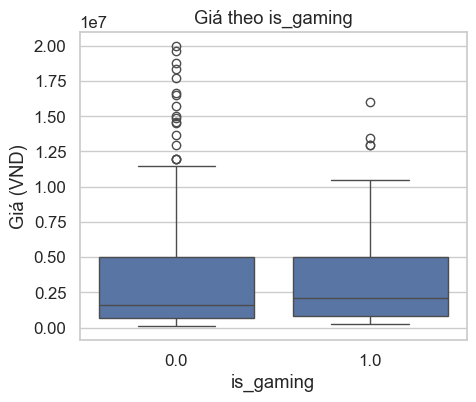

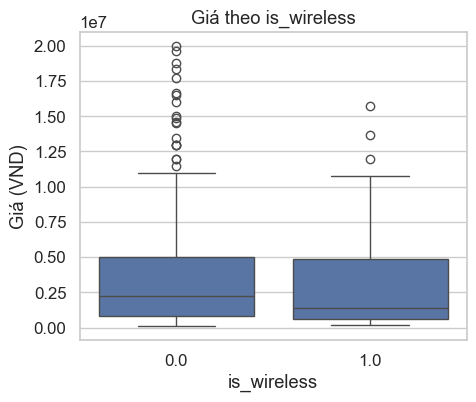

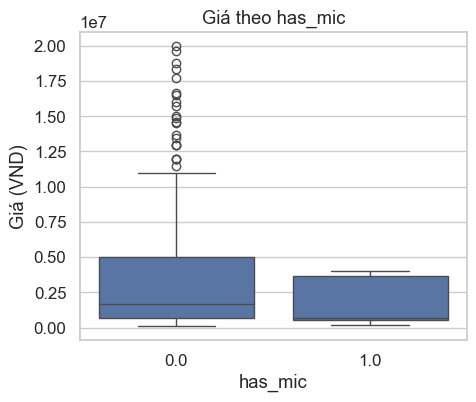

In [89]:
for col in ['is_gaming', 'is_wireless', 'has_mic']:
    if col in df.columns:
        plt.figure(figsize=(5,4))
        sns.boxplot(data=df, x=col, y='price_vnd')
        plt.title(f'Giá theo {col}')
        plt.xlabel(col)
        plt.ylabel('Giá (VND)')
        plt.show()


---
## 5. Trực quan hóa mối quan hệ đa biến (Bivariate & Multivariate Analysis)

Để trả lời cho câu hỏi "Có mối quan hệ tiềm ẩn nào giữa các đặc trưng phần cứng và giá thành hay không?", ta tiến hành vẽ các biểu đồ phân tích tương quan giữa biến mục tiêu (`price_vnd`) và các biến độc lập.


In [82]:
import matplotlib.ticker as ticker

# Nâng cấp giao diện chung cho tất cả biểu đồ (Font to hơn, nền trắng lưới xám sang trọng)
sns.set_theme(style="whitegrid", font_scale=1.1)

# Hàm rút gọn tiền tệ (Ví dụ: 5000000 -> 5 Tr)
def millions_formatter(x, pos):
    return f'{x * 1e-6:g} Tr'
formatter = ticker.FuncFormatter(millions_formatter)

### 5.1. Quan hệ giữa Giá và các yếu tố phần cứng dạng Numeric (Scatter Plot)

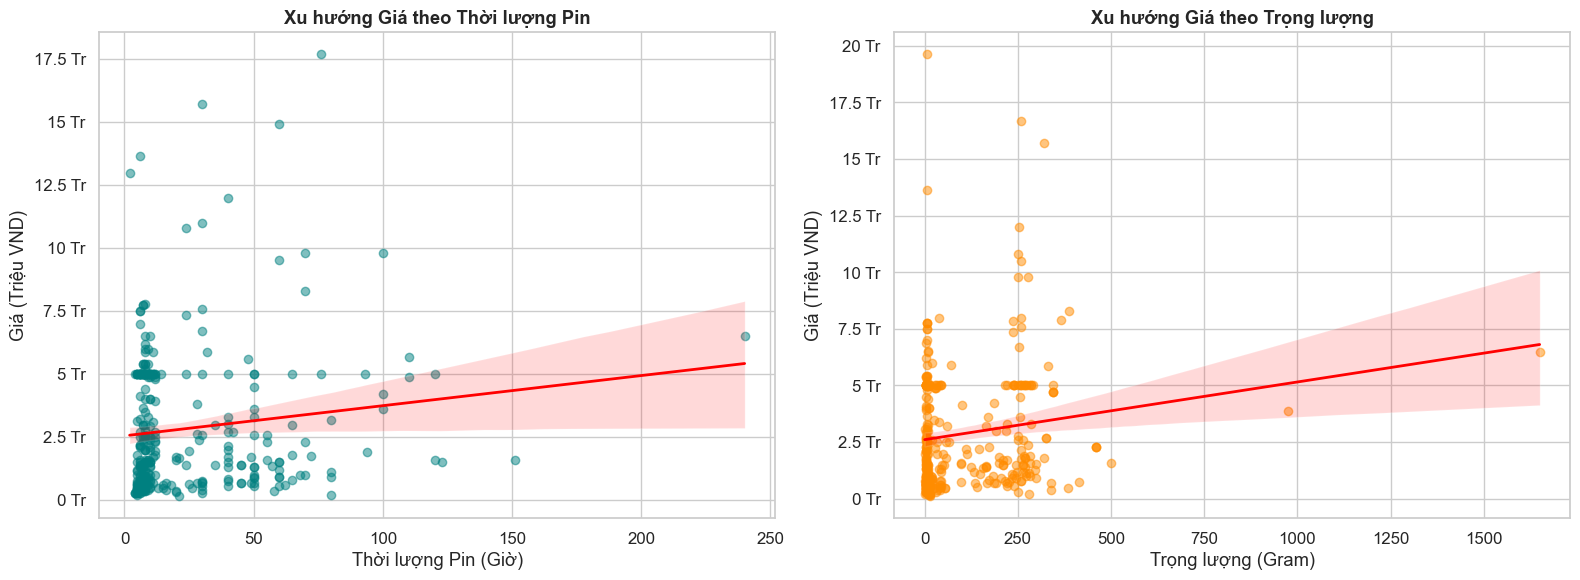

In [91]:
plt.figure(figsize=(16, 6))

# Đồ thị 1: Pin vs Giá
if 'battery_life_hours' in df.columns:
    ax1 = plt.subplot(1, 2, 1)
    # Dùng regplot thay vì scatterplot để vẽ luôn đường xu hướng màu đỏ
    sns.regplot(x=df['battery_life_hours'], y=df['price_vnd'], 
                scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red', 'lw':2})
    ax1.yaxis.set_major_formatter(formatter) # Áp dụng rút gọn tiền
    plt.title('Xu hướng Giá theo Thời lượng Pin', fontweight='bold')
    plt.xlabel('Thời lượng Pin (Giờ)')
    plt.ylabel('Giá (Triệu VND)')

# Đồ thị 2: Trọng lượng vs Giá
if 'weight_gram' in df.columns:
    ax2 = plt.subplot(1, 2, 2)
    sns.regplot(x=df['weight_gram'], y=df['price_vnd'], 
                scatter_kws={'alpha':0.5, 'color':'darkorange'}, line_kws={'color':'red', 'lw':2})
    ax2.yaxis.set_major_formatter(formatter)
    plt.title('Xu hướng Giá theo Trọng lượng', fontweight='bold')
    plt.xlabel('Trọng lượng (Gram)')
    plt.ylabel('Giá (Triệu VND)')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Price vs Battery Life:** Không có xu hướng tuyến tính quá mạnh. Các tai nghe đắt tiền nhất (Ultra-Premium) thường có thời lượng pin ở mức vừa phải (tập trung vào chất lượng âm thanh), trong khi các tai nghe pin cực "trâu" thường rơi vào phân khúc tầm trung.
- **Price vs Weight:** Các tai nghe có trọng lượng nặng (thường là tai nghe trùm đầu Over-ear trang bị nhiều củ loa và pin lớn) có xu hướng đạt mức giá cao hơn so với tai nghe nhẹ (In-ear).

### 5.2. Phân phối Giá theo Danh mục: Loại tai nghe và Thương hiệu (Box Plot)

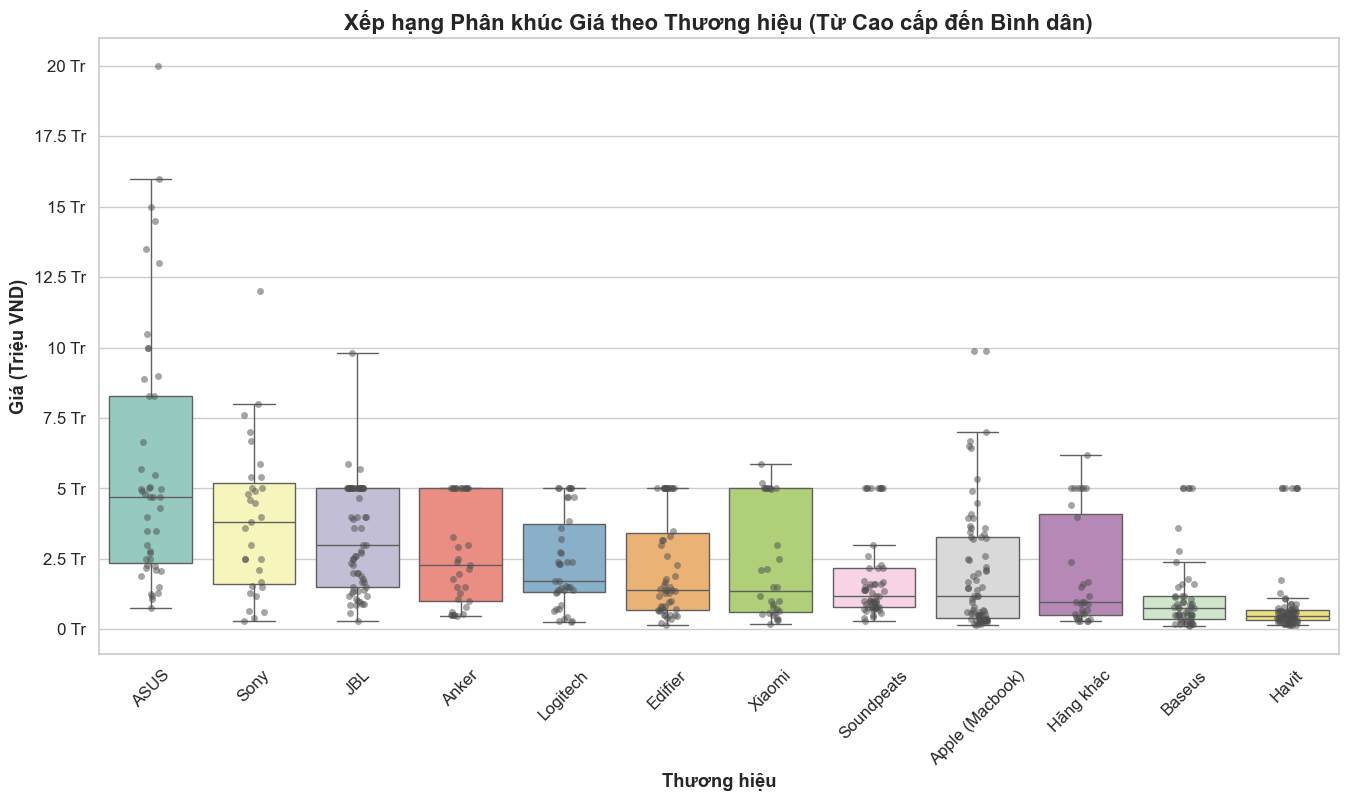

In [84]:
if 'brand' in df.columns:
    # Lấy top 12 hãng phổ biến nhất
    top_12_brands = df['brand'].value_counts().nlargest(12).index
    df_top_brands = df[df['brand'].isin(top_12_brands)]
    
    # SẮP XẾP các hãng theo giá trung vị (từ đắt đến rẻ)
    order = df_top_brands.groupby('brand')['price_vnd'].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(16, 8))
    ax = sns.boxplot(x='brand', y='price_vnd', data=df_top_brands, order=order, palette='Set3', showfliers=False)
    
    # Vẽ đè các điểm dữ liệu thực tế lên Boxplot (giúp thấy rõ sản phẩm nào siêu đắt)
    sns.stripplot(x='brand', y='price_vnd', data=df_top_brands, order=order, color=".3", alpha=0.5, jitter=True)
    
    ax.yaxis.set_major_formatter(formatter)
    plt.title("Xếp hạng Phân khúc Giá theo Thương hiệu (Từ Cao cấp đến Bình dân)", fontweight='bold', fontsize=16)
    plt.xlabel("Thương hiệu", fontweight='bold')
    plt.ylabel("Giá (Triệu VND)", fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

**Nhận xét:**
- **Theo Kiểu dáng:** Tai nghe Over-ear (trùm đầu) có mức giá trung vị và khoảng tứ phân vị (IQR) cao nhất, trong khi tai nghe In-ear/Earbuds phổ thông tập trung ở phân khúc giá rẻ.
- **Theo Thương hiệu:** Các hãng như Sony, Apple hay Sennheiser có độ phân tán giá (Variance) rất rộng và sở hữu nhiều điểm dị biệt (Outliers) ở mức giá rất cao, khẳng định vị thế ở phân khúc cao cấp. Các hãng như JBL, Logitech tập trung mạnh vào phân khúc tầm trung.

### 5.4. Ma trận tương quan tổng thể (Correlation Heatmap)


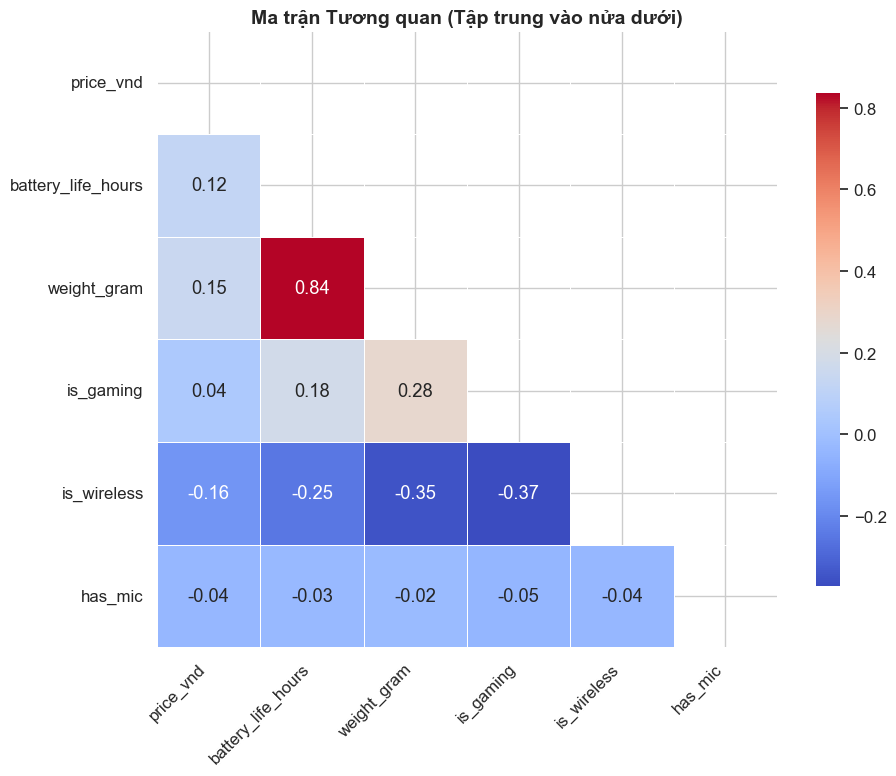

In [94]:
numeric_features_corr = ['price_vnd', 'battery_life_hours', 'weight_gram', 'is_gaming', 'is_wireless', 'is_tws', 'has_mic', 'price_per_driver_mm']
numeric_features_corr = [c for c in numeric_features_corr if c in df.columns]

if len(numeric_features_corr) > 1:
    plt.figure(figsize=(10, 8))
    corr = df[numeric_features_corr].corr()
    
    # TẠO MASK: Che đi nửa tam giác phía trên để biểu đồ không bị lặp lại và rối mắt
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", 
                linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title("Ma trận Tương quan (Tập trung vào nửa dưới)", fontweight='bold', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 6 . Trực quan hóa không gian đa chiều (Clustermap & t-SNE)

Sử dụng thuật toán học máy không giám sát t-SNE để giảm chiều dữ liệu không gian đặc trưng xuống 2D, kết hợp với Clustermap để quan sát sự phân cụm tự nhiên của thị trường tai nghe.

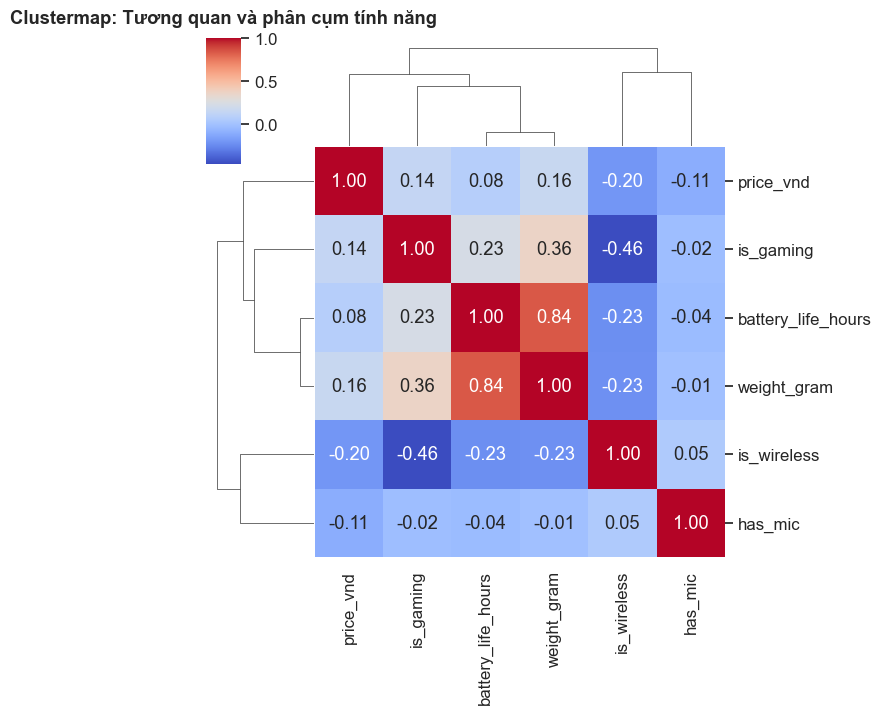

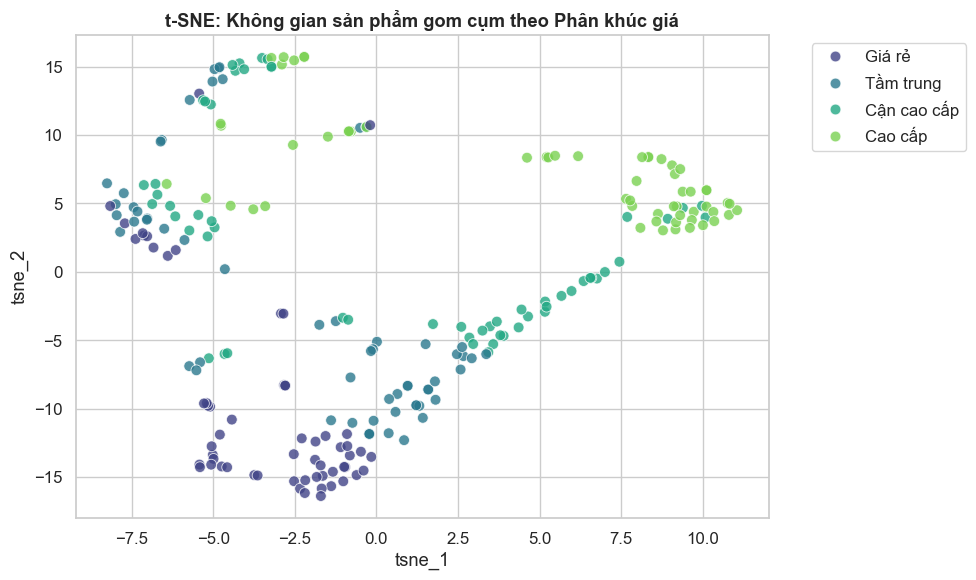

In [86]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Vẽ Clustermap
# ==========================================
numeric_cols_for_clustering = ['price_vnd', 'battery_life_hours', 'weight_gram', 'is_gaming', 'is_wireless', 'has_mic']
numeric_cols_for_clustering = [c for c in numeric_cols_for_clustering if c in df.columns]

# Bỏ qua các dòng có giá trị NaN
df_cluster = df[numeric_cols_for_clustering].dropna()

if len(df_cluster) > 0:
    # BƯỚC SỬA LỖI: Lọc bỏ các cột chỉ có 1 giá trị duy nhất (độ lệch chuẩn = 0)
    df_cluster_corr_data = df_cluster.loc[:, df_cluster.std() > 0]
    
    # Tính ma trận tương quan và lấp đầy NaN bằng 0 (nếu có)
    corr_matrix = df_cluster_corr_data.corr().fillna(0)
    
    sns.clustermap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", figsize=(7, 7))
    plt.title("Clustermap: Tương quan và phân cụm tính năng", y=1.05, fontweight='bold')
    plt.show()

# ==========================================
# 2. Chạy t-SNE
# ==========================================
if len(df_cluster) > 30: # Cần đủ số mẫu
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_cluster)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_results = tsne.fit_transform(scaled_features)
    
    df_cluster['tsne_1'] = tsne_results[:, 0]
    df_cluster['tsne_2'] = tsne_results[:, 1]
    
    # Chia phân khúc giá để tô màu
    df_cluster['price_category'] = pd.qcut(df_cluster['price_vnd'], q=4, labels=['Giá rẻ', 'Tầm trung', 'Cận cao cấp', 'Cao cấp'])
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_cluster, x='tsne_1', y='tsne_2', hue='price_category', palette='viridis', s=60, alpha=0.8)
    plt.title("t-SNE: Không gian sản phẩm gom cụm theo Phân khúc giá", fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

---
## 7. Kết luận đánh giá khả thi

Dựa trên quá trình thu thập, làm sạch và phân tích khám phá (EDA) trên hơn 1000 mẫu dữ liệu, nhóm rút ra kết luận:

**1. Tính khả thi của bài toán:**
Bài toán dự đoán giá tai nghe (Hồi quy) là **HOÀN TOÀN KHẢ THI**. 
- Dữ liệu thu thập đủ lớn và đa dạng.
- Ma trận tương quan và Clustermap cho thấy có sự liên kết tuyến tính rõ rệt giữa biến mục tiêu (`price_vnd`) và các đặc trưng kỹ thuật cốt lõi (như có tính năng không dây `is_wireless`, thời lượng pin, và yếu tố thương hiệu).
- Biểu đồ t-SNE chứng minh dữ liệu có tính phân cụm rất tốt; các sản phẩm có cùng phân khúc giá có xu hướng tụ lại thành những ranh giới rõ ràng, tạo điều kiện thuận lợi cho các thuật toán Machine Learning phân tách và học tập.

**2. Tập đặc trưng (Features) đề xuất cho mô hình dự đoán:**
- **Đặc trưng thông số kỹ thuật (Numeric):** `battery_life_hours`, `weight_gram`, `price_per_driver_mm`.
- **Đặc trưng tính năng (Boolean):** `is_wireless`, `is_gaming`, `has_mic`.
- **Đặc trưng danh mục (One-Hot Encoded):** `brand_grouped` (đã lọc các hãng lớn) và `type`.

---

## 8. Tài liệu tham khảo

- Gợi ý nguồn dữ liệu: `gearvn.com`, `cellphones.com.vn`, `phongvu.vn`, `pcpartpicker.com`, Tiki/Shopee (category tai nghe/headphone).
- Kỹ thuật Feature Engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- Giới thiệu t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne
- Cách trình bày notebook tham khảo: folder mẫu 10-Data-Capstone-Projects (GV cung cấp).
